# Importing Libraries

In [276]:
#%pip install imblearn

In [277]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Importing and Merging Data


In [278]:
train_identity_df = pd.read_csv("globalmart_train_identity.csv")
train_transactions_df = pd.read_csv("globalmart_train_transactions.csv")
train_df = pd.merge(train_transactions_df, train_identity_df, on='OrderID', how='left')
print("Train Indentity Data Shape:", train_identity_df.shape)
print("Train Transactions Data Shape:", train_transactions_df.shape)
print("Merged Training Data Shape:", train_df.shape)
train_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_16220\2522236910.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  train_identity_df = pd.read_csv("globalmart_train_identity.csv")


Train Indentity Data Shape: (40003, 41)
Train Transactions Data Shape: (40000, 394)
Merged Training Data Shape: (40000, 434)


,OrderID,IsRisky,OrderTimestamp,OrderAmount,PaymentType,CardInfo1,CardInfo2,CardInfo3,CardNetwork,CardInfo5,...,IdentityFeature31,IdentityFeature32,IdentityFeature33,IdentityFeature34,IdentityFeature35,IdentityFeature36,IdentityFeature37,IdentityFeature38,DeviceOS,DeviceModel
0,3229860,0,5767952,57.950,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3510768,0,13749040,47.950,W,4921,475.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3055818,0,1550092,100.000,R,9472,399.0,150.0,american express,102.0,...,safari generic,24.0,1440x900,match_status:2,T,F,T,F,desktop,MacOS
3,3272931,0,7009615,35.950,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3510649,1,13745920,18.936,C,13832,375.0,185.0,mastercard,224.0,...,mobile safari 11.0,NaN,NaN,NaN,F,F,F,F,mobile,NaN


In [279]:
test_identity_df = pd.read_csv("globalmart_test_identity.csv")
test_transactions_df = pd.read_csv("globalmart_test_transactions.csv")
test_df = pd.merge(test_transactions_df, test_identity_df, on='OrderID', how='left')

print("Test Indentity Data Shape:", test_identity_df.shape)
print("Test Transactions Data Shape:", test_transactions_df.shape)
print("Merged Testing Data Shape:", test_df.shape)
test_df.head()

Test Indentity Data Shape: (10000, 41)
Test Transactions Data Shape: (10000, 393)
Merged Testing Data Shape: (10000, 433)


,OrderID,OrderTimestamp,OrderAmount,PaymentType,CardInfo1,CardInfo2,CardInfo3,CardNetwork,CardInfo5,CardType,...,IdentityFeature31,IdentityFeature32,IdentityFeature33,IdentityFeature34,IdentityFeature35,IdentityFeature36,IdentityFeature37,IdentityFeature38,DeviceOS,DeviceModel
0,3338269,8650539,39.00,W,7987,532.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3458767,12177840,77.00,W,5973,354.0,143.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3172275,4126113,54.50,W,9500,321.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3417124,10870646,159.95,W,2803,100.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3501281,13461665,57.95,W,9500,321.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploring Data

Target Variable Distribution (IsRisky):
IsRisky
0    0.965
1    0.035
Name: proportion, dtype: float64


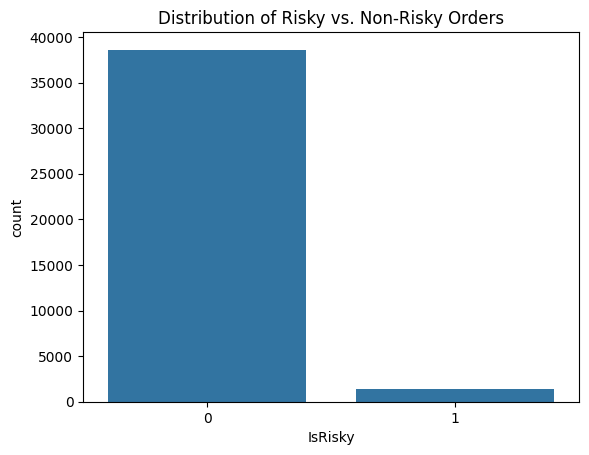

Top 30 columns with the most missing values:
                   count  percentage
IdentityFeature24  39716     99.2900
IdentityFeature25  39698     99.2450
IdentityFeature21  39695     99.2375
IdentityFeature8   39695     99.2375
IdentityFeature7   39695     99.2375
IdentityFeature26  39694     99.2350
IdentityFeature22  39694     99.2350
IdentityFeature23  39694     99.2350
IdentityFeature27  39694     99.2350
IdentityFeature18  37477     93.6925
dist2              37477     93.6925
TimeDelta7         37405     93.5125
IdentityFeature4   36329     90.8225
IdentityFeature3   36329     90.8225
IdentityFeature33  35854     89.6350
IdentityFeature9   35847     89.6175
TimeDelta13        35847     89.6175
IdentityFeature10  35847     89.6175
TimeDelta14        35827     89.5675
TimeDelta12        35695     89.2375
IdentityFeature30  35614     89.0350
IdentityFeature32  35613     89.0325
IdentityFeature34  35586     88.9650
IdentityFeature14  35460     88.6500
TimeDelta6         35126     8

In [280]:
print("Target Variable Distribution (IsRisky):")
print(train_df['IsRisky'].value_counts(normalize=True))

sns.countplot(x='IsRisky', data=train_df)
plt.title('Distribution of Risky vs. Non-Risky Orders')
plt.show()


def get_missing_value_summary(df):
    """Calculates and returns a DataFrame with missing value counts and percentages."""
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({'count': missing_count, 'percentage': missing_percentage})
    return missing_df.sort_values(by='percentage', ascending=False)

missing_summary = get_missing_value_summary(train_df)
print("Top 30 columns with the most missing values:")
print(missing_summary.head(30))

# 3. Identify Numerical and Categorical Features
categorical_features = train_df.select_dtypes(include=['object']).columns
numerical_features = train_df.select_dtypes(include=np.number).columns

print(f"\nFound {len(categorical_features)} categorical features.")
print(f"Found {len(numerical_features)} numerical features.")

# Preprocessing

In [281]:
missing_threshold = 92
cols_to_drop = missing_summary[missing_summary['percentage'] > missing_threshold].index
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns. New shape of train_df: {train_df.shape}")

categorical_features = train_df.select_dtypes(include=['object']).columns
numerical_features = train_df.select_dtypes(include=np.number).columns

for col in numerical_features:
    if col not in ['OrderID', 'IsRisky']:
        median_val = train_df[col].median()
        train_df[col].fillna(median_val, inplace=True)
        test_df[col].fillna(median_val, inplace=True)
        
for col in categorical_features:
    train_df[col].fillna("Missing", inplace=True)
    test_df[col].fillna("Missing", inplace=True)

print("\nTotal missing values in training data after imputation:", train_df.isnull().sum().sum())
print("Total missing values in testing data after imputation:", test_df.isnull().sum().sum())

Dropped 12 columns. New shape of train_df: (40000, 422)

Total missing values in training data after imputation: 0
Total missing values in testing data after imputation: 0


**Time-Based Features from OrderTimestamp:** The timestamp is just seconds from a reference point. We can extract more human-interpretable patterns from it. Risky transactions often occur at unusual times (e.g., very late at night).

Logic: We can convert the timestamp to represent the hour of the day and the day of the week.

- Feature 1: hour_of_day

- Feature 2: day_of_week


**Order Amount Decimal Feature:** In fraud detection, the decimal part of a transaction amount can be a surprisingly strong signal. Prices for legitimate goods often end in .99 or .95, while fraudulent or automated transactions might use round numbers or have random decimals.

Logic: Extract the fractional part of the OrderAmount.

- Feature 3: order_amount_decimal

# Feature Engineering

In [282]:
SECONDS_IN_DAY = 24 * 60 * 60
train_df['hour_of_day'] = (train_df['OrderTimestamp'] // 3600) % 24
train_df['day_of_week'] = (train_df['OrderTimestamp'] // SECONDS_IN_DAY) % 7

test_df['hour_of_day'] = (test_df['OrderTimestamp'] // 3600) % 24
test_df['day_of_week'] = (test_df['OrderTimestamp'] // SECONDS_IN_DAY) % 7

print("Created 'hour_of_day' and 'day_of_week' features.")

train_df['order_amount_decimal'] = train_df['OrderAmount'] - np.floor(train_df['OrderAmount'])
test_df['order_amount_decimal'] = test_df['OrderAmount'] - np.floor(test_df['OrderAmount'])

print("Created 'order_amount_decimal' feature.")

train_df.head()

Created 'hour_of_day' and 'day_of_week' features.
Created 'order_amount_decimal' feature.


,OrderID,IsRisky,OrderTimestamp,OrderAmount,PaymentType,CardInfo1,CardInfo2,CardInfo3,CardNetwork,CardInfo5,...,IdentityFeature34,IdentityFeature35,IdentityFeature36,IdentityFeature37,IdentityFeature38,DeviceOS,DeviceModel,hour_of_day,day_of_week,order_amount_decimal
0,3229860,0,5767952,57.950,W,12695,490.0,150.0,visa,226.0,...,Missing,Missing,Missing,Missing,Missing,Missing,Missing,18,3,0.950
1,3510768,0,13749040,47.950,W,4921,475.0,150.0,visa,226.0,...,Missing,Missing,Missing,Missing,Missing,Missing,Missing,3,5,0.950
2,3055818,0,1550092,100.000,R,9472,399.0,150.0,american express,102.0,...,match_status:2,T,F,T,F,desktop,MacOS,22,3,0.000
3,3272931,0,7009615,35.950,W,12695,490.0,150.0,visa,226.0,...,Missing,Missing,Missing,Missing,Missing,Missing,Missing,3,4,0.950
4,3510649,1,13745920,18.936,C,13832,375.0,185.0,mastercard,224.0,...,Missing,F,F,F,F,mobile,Missing,2,5,0.936


In [283]:
categorical_features = train_df.select_dtypes(include=['object']).columns

# Creates a new column for every categorical feature
for col in categorical_features:
    # Calculate counts on combined data to ensure consistency
    combined_series = pd.concat([train_df[col], test_df[col]], axis=0)
    count_map = combined_series.value_counts().to_dict()
    
    train_df[f'{col}_count'] = train_df[col].map(count_map)
    test_df[f'{col}_count'] = test_df[col].map(count_map)

print("Frequency features created.")


for col in categorical_features:
    le = LabelEncoder()
    le.fit(list(train_df[col].astype(str).values) + list(test_df[col].astype(str).values))
    
    train_df[col] = le.transform(list(train_df[col].astype(str).values))
    test_df[col] = le.transform(list(test_df[col].astype(str).values))

print("All categorical features have been Label Encoded.")
train_df.head()

Frequency features created.
All categorical features have been Label Encoded.


,OrderID,IsRisky,OrderTimestamp,OrderAmount,PaymentType,CardInfo1,CardInfo2,CardInfo3,CardNetwork,CardInfo5,...,IdentityFeature30_count,IdentityFeature31_count,IdentityFeature33_count,IdentityFeature34_count,IdentityFeature35_count,IdentityFeature36_count,IdentityFeature37_count,IdentityFeature38_count,DeviceOS_count,DeviceModel_count
0,20593,0,5767952,57.950,4,12695,490.0,150.0,4,226.0,...,44374,39828,44695,44338,39774,39774,39774,39774,39781,41433
1,44351,0,13749040,47.950,4,4921,475.0,150.0,4,226.0,...,44374,39828,44695,44338,39774,39774,39774,39774,39781,41433
2,5893,0,1550092,100.000,2,9472,399.0,150.0,1,102.0,...,129,618,308,4348,5649,9703,8008,5407,6183,925
3,24244,0,7009615,35.950,4,12695,490.0,150.0,4,226.0,...,44374,39828,44695,44338,39774,39774,39774,39774,39781,41433
4,44338,1,13745920,18.936,0,13832,375.0,185.0,3,224.0,...,44374,984,44695,44338,4577,9703,2218,5407,4036,41433


# Model Training 1

# Model Training 2

In [ ]:
X = train_df.drop(columns=['OrderID', 'IsRisky',"IdentityFeature35_count",'IdentityFeature28_count','IdentityFeature37_count','MatchStatus1_count','V16','V14','V1','OrderID_count','V89','V88','V247','V241','V240','V197','V198','V196','V193','V191','MatchStatus2_count','V154','V153','V93','V68','V269','V41','V65','V305','V107','V113','V138','V142','V322','V325','V329','V108','V119','V27','V28','V116','V117'])
X = X.drop(columns=["IdentityFeature10"]) #n_estimators=1483 ->0.6376
y = train_df['IsRisky']
X_test = test_df.drop(columns=['OrderID'])
X_test = X_test[X.columns]

# Calculate scale_pos_weight for handling imbalance
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the LightGBM model
lgbm = lgb.LGBMClassifier(objective='binary',
                          n_estimators=1483, # Can be tuned #1483->0.6376
                          learning_rate=0.05,
                          num_leaves=30,
                          scale_pos_weight=scale_pos_weight,
                          random_state=42,
                          n_jobs=-1)

print("\nTraining LightGBM model...\n")
lgbm.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         eval_metric='f1',
         callbacks=[lgb.early_stopping(100, verbose=False)]) # Early stopping to prevent overfitting

y_pred_val = lgbm.predict(X_val)
f1 = f1_score(y_val, y_pred_val)

print(f"\nF1-Score on Validation Set: {f1:.4f}")
print("\nClassification Report on Validation Set:")
print(classification_report(y_val, y_pred_val))

Scale Pos Weight: 27.57

Training LightGBM model...

[LightGBM] [Info] Number of positive: 1120, number of negative: 30880
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28958
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 412
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035000 -> initscore=-3.316780
[LightGBM] [Info] Start training from score -3.316780

F1-Score on Validation Set: 0.0000

Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7720
           1       0.00      0.00      0.00       280

    accuracy                           0.96      8000
   macro avg       0.48      0.50      0.49      8000
weighted avg       0.93      0.96      0.95      8000



c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [285]:
print("\nRetraining model on the full training dataset...")
lgbm.fit(X, y)

print("Making predictions on the test dataset...")
test_predictions = lgbm.predict(X_test)

test_df_2 = pd.merge(test_transactions_df, test_identity_df, on='OrderID', how='left')

submission_df = pd.DataFrame({
    'OrderID': test_df_2['OrderID'],
    'IsRisky': test_predictions
})

submission_df.to_csv('submission_2.csv', index=False)

print("\nSubmission file 'submission_2.csv' created successfully!")
submission_df.head()



Retraining model on the full training dataset...
[LightGBM] [Info] Number of positive: 1400, number of negative: 38600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30151
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 412
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035000 -> initscore=-3.316780
[LightGBM] [Info] Start training from score -3.316780
Making predictions on the test dataset...

Submission file 'submission_2.csv' created successfully!


,OrderID,IsRisky
0,3338269,0
1,3458767,0
2,3172275,0
3,3417124,0
4,3501281,0


In [286]:
importances = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
low_importance = importances[importances < importances.max() * 0.01]  # Threshold: <1% of top
print("Low importance features:\n", low_importance)

Low importance features:
 V295    24
V279    24
V272    24
V290    24
V293    24
        ..
V195     0
V122     0
V327     0
V155     0
V334     0
Length: 215, dtype: int32
